# News & Macro Agent Prototype

This notebook runs the News & Macro Agent as an event-driven second-order investment idea generator. You can paste one news article directly, or fetch recent context for a ticker when optional packages and API keys are configured.

In [1]:
import sys
from pathlib import Path
from dotenv import load_dotenv

# Works when the notebook is launched from either the repo root or notebooks/.
CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = CURRENT_DIR if (CURRENT_DIR / "pyproject.toml").exists() else CURRENT_DIR.parent

sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "src"))

loaded_env = load_dotenv(REPO_ROOT / ".env")
print(f"Repo root: {REPO_ROOT}")
print(f"Loaded .env: {loaded_env}")


Repo root: /Users/zhang/Github/OpenClam_Multi-Agent_Investment_Advisory
Loaded .env: True


In [ ]:
import importlib
import openclam.agents.news_macro.news_macro_agent as news_macro_agent

# Reload while iterating locally so Jupyter does not keep an older dataclass definition.
news_macro_agent = importlib.reload(news_macro_agent)

analyze_news_text = news_macro_agent.analyze_news_text
collect_context = news_macro_agent.collect_context
display_report = news_macro_agent.display_report
generate_report = news_macro_agent.generate_report
save_report = news_macro_agent.save_report

mag7_q4_2025_earnings_df = news_macro_agent.mag7_q4_2025_earnings_df
build_earnings_price_eval = news_macro_agent.build_earnings_price_eval
format_return_columns = news_macro_agent.format_return_columns
plot_earnings_eval = news_macro_agent.plot_earnings_eval
run_agent_event_window_eval = news_macro_agent.run_agent_event_window_eval
summarize_eval_results = news_macro_agent.summarize_eval_results
to_cio_agent_input = news_macro_agent.to_cio_agent_input


print(f"Loaded news_macro_agent from: {news_macro_agent.__file__}")


In [26]:
TICKER = 'NVDA'
COMPANY = 'NVIDIA'
EVENT_DATE = '2026-01-26'
LOOKBACK_DAYS = 14
NEWS_MODE =  "event_window"  # use "event_window" for historical case studies，use "latest" for newest event

## Fetch ticker context

Use this path when `yfinance` or `NEWSAPI_KEY` is configured.

In [ ]:
context = collect_context(
    ticker=TICKER,
    company=COMPANY,
    event_date=EVENT_DATE,
    lookback_days=LOOKBACK_DAYS,
    max_news=10,
    news_mode=NEWS_MODE,
)

context

In [ ]:
fetched_report = generate_report(context)
display_report(fetched_report)

## Next integration step

Later, the CIO agent can consume `report` directly because it already contains a structured summary, core insight, investment opportunities, risk notes, citations, and raw context.


In [ ]:
# Standard CIO packet showcase for News/Macro output
# Other agents should expose the same shape before CIO aggregation.
cio_inputs = {
    TICKER: to_cio_agent_input(fetched_report)
}

cio_inputs[TICKER]


## Evaluation: Q4 2025 Earnings Window for Magnificent Seven

This section runs a post-earnings event-window test: the agent can see news through the earnings date, then we compare short-term stance against the next 7-trading-day abnormal return vs QQQ and medium-term stance against the next 30-trading-day abnormal return vs QQQ. Most evaluation logic lives in `news_macro_agent.py`; the notebook only displays results.


In [27]:
PRE_TRADING_DAYS = 7
POST_TRADING_DAYS = 7
LONG_POST_TRADING_DAYS = 30
LOOKBACK_DAYS = 14

earnings_df = mag7_q4_2025_earnings_df()
earnings_df


,ticker,company,earnings_date
0,TSLA,Tesla,2026-01-28
1,META,Meta Platforms,2026-01-28
2,AAPL,Apple,2026-01-29
3,MSFT,Microsoft,2026-01-28
4,GOOGL,Alphabet,2026-02-03
5,AMZN,Amazon,2026-02-05
6,NVDA,Nvidia,2026-02-25


In [28]:
summary_df, paths_df = build_earnings_price_eval(
    earnings_df=earnings_df,
    pre_trading_days=PRE_TRADING_DAYS,
    post_trading_days=POST_TRADING_DAYS,
    long_post_trading_days=LONG_POST_TRADING_DAYS,
    benchmarks=("SPY", "QQQ"),
)

format_return_columns(summary_df)


,ticker,company,earnings_date,pre_7d_return,post_1d_return,post_3d_return,post_7d_return,post_30d_return,full_window_return,full_30d_window_return,...,abnormal_vs_spy,spy_post_30d_return,abnormal_30d_vs_spy,qqq_post_7d_return,abnormal_vs_qqq,qqq_post_30d_return,abnormal_30d_vs_qqq,realized_direction_vs_qqq,realized_30d_direction_vs_qqq,long_horizon_trading_days
0,TSLA,Tesla,2026-01-28,-1.75%,0.13%,-0.11%,-7.82%,-5.36%,-9.43%,-7.01%,...,-5.25%,-2.75%,-2.60%,-5.40%,-2.42%,-3.71%,-1.64%,down,down,30
1,META,Meta Platforms,2026-01-28,8.40%,-0.63%,6.47%,-0.41%,-2.69%,7.96%,5.49%,...,2.16%,-2.75%,0.06%,-5.40%,4.99%,-3.71%,1.02%,up,up,30
2,AAPL,Apple,2026-01-29,0.36%,0.72%,5.29%,8.45%,-0.17%,8.84%,0.18%,...,9.14%,-4.22%,4.05%,-3.72%,12.18%,-5.68%,5.51%,up,up,30
3,MSFT,Microsoft,2026-01-28,5.24%,0.22%,-10.46%,-18.08%,-15.56%,-13.79%,-11.14%,...,-15.51%,-2.75%,-12.80%,-5.40%,-12.68%,-3.71%,-11.85%,down,down,30
4,GOOGL,Alphabet,2026-02-03,3.98%,-1.16%,-3.62%,-9.52%,-9.47%,-5.92%,-5.87%,...,-9.03%,-3.54%,-5.93%,-2.08%,-7.44%,-3.65%,-5.82%,down,down,30
5,AMZN,Amazon,2026-02-05,-2.28%,-4.42%,-10.42%,-14.68%,-10.40%,-16.62%,-12.44%,...,-14.03%,-3.85%,-6.55%,-0.63%,-14.05%,-2.10%,-8.30%,down,down,30
6,NVDA,Nvidia,2026-02-25,3.16%,1.41%,-8.12%,-4.93%,-5.58%,-1.93%,-2.59%,...,-4.05%,-1.38%,-4.20%,0.17%,-5.10%,-0.17%,-5.41%,down,down,30


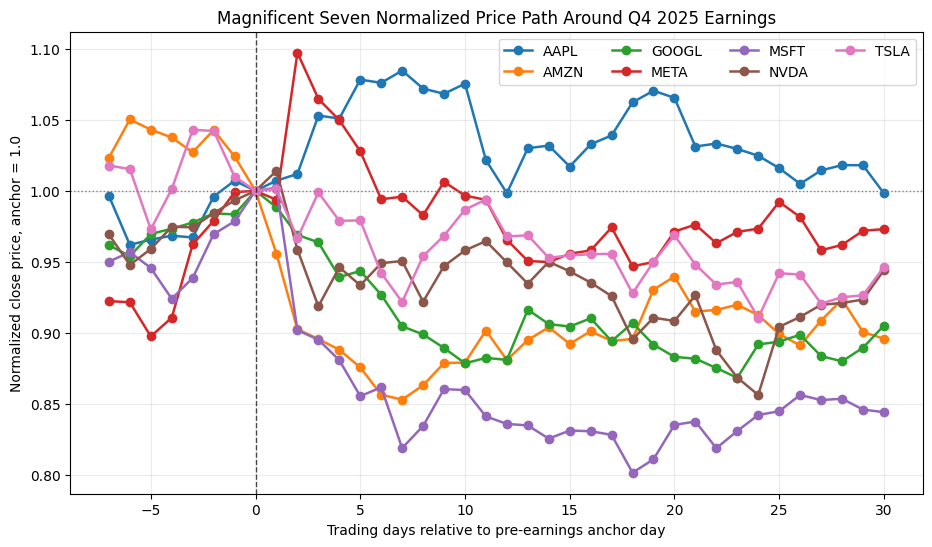

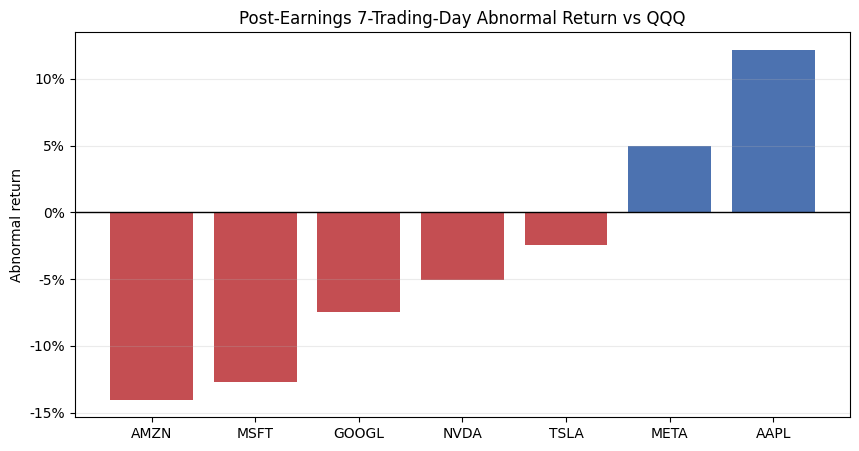

In [29]:
plot_earnings_eval(summary_df, paths_df)


In [30]:
agent_eval_hook, agent_reports = run_agent_event_window_eval(
    summary_df,
    lookback_days=LOOKBACK_DAYS,
    max_news=10,
    news_sources=["finnhub", "newsapi", "yfinance"],
    provider="auto",
    model="gpt-5.4-nano",
    gemini_model="gemini-2.5-flash",
    neutral_band=0.02,
    long_post_trading_days=LONG_POST_TRADING_DAYS,
    news_end_offset_days=0,  # post-earnings: include news through earnings date
    quiet=True,
)

agent_eval_hook


,ticker,company,earnings_date,post_7d_return,abnormal_vs_qqq,realized_direction_vs_qqq,post_30d_return,abnormal_30d_vs_qqq,realized_30d_direction_vs_qqq,news_context_ready,...,agent_stance,agent_confidence,confidence_rationale,stance_rationale,short_direction_match,short_direction_match_reason,long_direction_match,long_direction_match_reason,direction_match,direction_match_reason
0,TSLA,Tesla,2026-01-28,-0.078185,-0.024155,down,-0.053562,-0.016423,down,True,...,ST: Bearish; LT: Neutral,0.46,Confidence is moderate-low because the window ...,"Short term, the strongest direct evidence is t...",True,matched,True,neutral matched: abnormal return stayed within...,True,matched
1,META,Meta Platforms,2026-01-28,-0.004101,0.049929,up,-0.026911,0.010229,up,True,...,ST: Bearish; LT: Bullish,0.62,Confidence is moderate because the window cont...,"Short term, the strongest direct signal is inv...",False,missed,True,matched,False,missed
2,AAPL,Apple,2026-01-29,0.084542,0.121764,up,-0.001719,0.055070,up,True,...,ST: Bearish; LT: Neutral,0.56,Confidence is moderate because there is direct...,"Short term (1-10 days), the strongest direct A...",False,missed,False,neutral missed: abnormal return moved outside ...,False,missed
3,MSFT,Microsoft,2026-01-28,-0.180844,-0.126814,down,-0.155595,-0.118455,down,True,...,ST: Bearish; LT: Bullish,0.46,Confidence is moderate-to-low because the wind...,"Short term, the strongest evidence is not a sp...",True,matched,False,missed,True,matched
4,GOOGL,Alphabet,2026-02-03,-0.095231,-0.074421,down,-0.094711,-0.058249,down,True,...,ST: Neutral; LT: Bullish,0.42,Confidence is moderate-low because the stronge...,Direct main-ticker evidence is mostly sentimen...,False,neutral missed: abnormal return moved outside ...,False,missed,False,neutral missed: abnormal return moved outside ...
5,AMZN,Amazon,2026-02-05,-0.146787,-0.140465,down,-0.103996,-0.082981,down,True,...,ST: Bearish; LT: Bullish,0.46,Confidence is moderate-low because the stronge...,"Short term, the dominant setup is risk-off/vol...",True,matched,False,missed,True,matched
6,NVDA,Nvidia,2026-02-25,-0.049313,-0.051024,down,-0.055795,-0.054124,down,True,...,ST: Bullish; LT: Bullish,0.62,Confidence is moderate because the NVDA-specif...,"Short term, the strongest evidence is direct m...",False,missed,False,missed,False,missed


In [31]:
format_return_columns(agent_eval_hook)


,ticker,company,earnings_date,post_7d_return,abnormal_vs_qqq,realized_direction_vs_qqq,post_30d_return,abnormal_30d_vs_qqq,realized_30d_direction_vs_qqq,news_context_ready,...,agent_stance,agent_confidence,confidence_rationale,stance_rationale,short_direction_match,short_direction_match_reason,long_direction_match,long_direction_match_reason,direction_match,direction_match_reason
0,TSLA,Tesla,2026-01-28,-7.82%,-2.42%,down,-5.36%,-1.64%,down,True,...,ST: Bearish; LT: Neutral,0.46,Confidence is moderate-low because the window ...,"Short term, the strongest direct evidence is t...",True,matched,True,neutral matched: abnormal return stayed within...,True,matched
1,META,Meta Platforms,2026-01-28,-0.41%,4.99%,up,-2.69%,1.02%,up,True,...,ST: Bearish; LT: Bullish,0.62,Confidence is moderate because the window cont...,"Short term, the strongest direct signal is inv...",False,missed,True,matched,False,missed
2,AAPL,Apple,2026-01-29,8.45%,12.18%,up,-0.17%,5.51%,up,True,...,ST: Bearish; LT: Neutral,0.56,Confidence is moderate because there is direct...,"Short term (1-10 days), the strongest direct A...",False,missed,False,neutral missed: abnormal return moved outside ...,False,missed
3,MSFT,Microsoft,2026-01-28,-18.08%,-12.68%,down,-15.56%,-11.85%,down,True,...,ST: Bearish; LT: Bullish,0.46,Confidence is moderate-to-low because the wind...,"Short term, the strongest evidence is not a sp...",True,matched,False,missed,True,matched
4,GOOGL,Alphabet,2026-02-03,-9.52%,-7.44%,down,-9.47%,-5.82%,down,True,...,ST: Neutral; LT: Bullish,0.42,Confidence is moderate-low because the stronge...,Direct main-ticker evidence is mostly sentimen...,False,neutral missed: abnormal return moved outside ...,False,missed,False,neutral missed: abnormal return moved outside ...
5,AMZN,Amazon,2026-02-05,-14.68%,-14.05%,down,-10.40%,-8.30%,down,True,...,ST: Bearish; LT: Bullish,0.46,Confidence is moderate-low because the stronge...,"Short term, the dominant setup is risk-off/vol...",True,matched,False,missed,True,matched
6,NVDA,Nvidia,2026-02-25,-4.93%,-5.10%,down,-5.58%,-5.41%,down,True,...,ST: Bullish; LT: Bullish,0.62,Confidence is moderate because the NVDA-specif...,"Short term, the strongest evidence is direct m...",False,missed,False,missed,False,missed


In [32]:
eval_summary = summarize_eval_results(agent_eval_hook)
eval_summary


{'cases': 7,
 'short_evaluable_cases': 7,
 'short_matched_cases': 3,
 'short_missed_cases': 4,
 'short_accuracy': 0.42857142857142855,
 'short_neutral_rate': 0.14285714285714285,
 'short_not_evaluable_cases': 0,
 'short_reason_counts': {'matched': 3,
  'missed': 3,
  'neutral missed: abnormal return moved outside +/-2%': 1},
 'long_evaluable_cases': 7,
 'long_matched_cases': 2,
 'long_missed_cases': 5,
 'long_accuracy': 0.2857142857142857,
 'long_neutral_rate': 0.2857142857142857,
 'long_not_evaluable_cases': 0,
 'long_reason_counts': {'missed': 4,
  'neutral matched: abnormal return stayed within +/-2%': 1,
  'matched': 1,
  'neutral missed: abnormal return moved outside +/-2%': 1}}